In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import plot_model
from sklearn.utils.class_weight import compute_class_weight
import os

In [4]:
image_generator = ImageDataGenerator(
    rescale=1.0 / 255.0,
    shear_range=0.1,
    zoom_range=0.3
)
image_generator_test = ImageDataGenerator(
    rescale=1.0 / 255.0
)

In [5]:
datasetTrain = os.path.join('datasets', 'XRay', 'Train')
datasetTest = os.path.join('datasets', 'XRay', 'Test')

In [6]:
train_data = image_generator.flow_from_directory(
    datasetTrain,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=16
)

Found 600 images belonging to 2 classes.


In [7]:
test_data = image_generator.flow_from_directory(
    datasetTest,
    target_size=(224, 224),
    color_mode='grayscale',
    class_mode='binary',
    batch_size=16
)

Found 150 images belonging to 2 classes.


In [8]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/home/docroch/Projects/learning-data-science/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

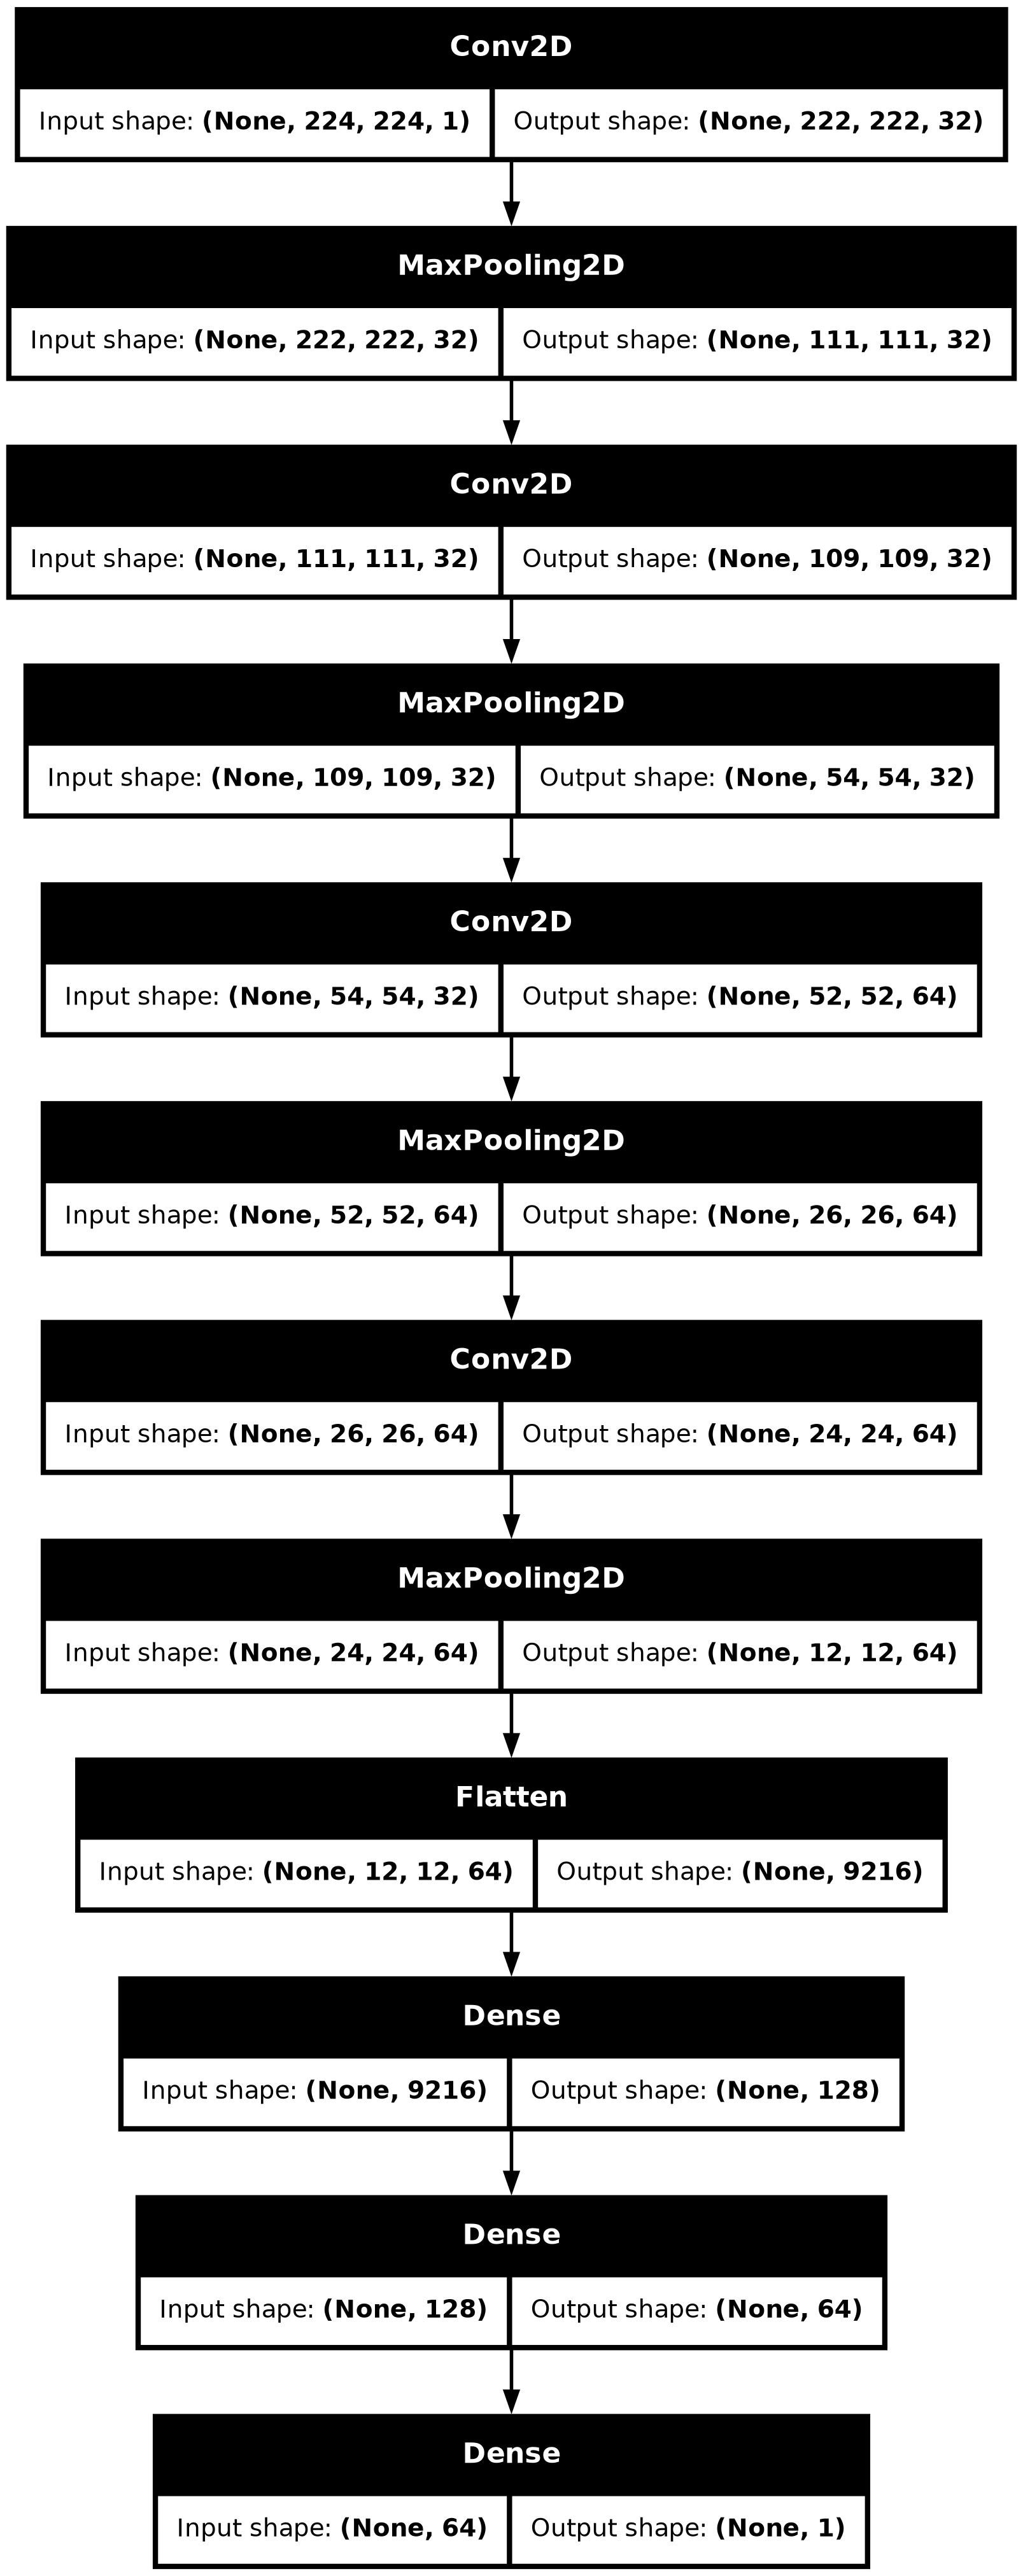

In [10]:
plot_model(model, show_shapes=True, show_layer_names=False)

In [11]:
train_data.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [12]:
compute_class_weight(class_weight='balanced', classes=np.unique(train_data.classes), y=train_data.classes)

array([1.5 , 0.75])

In [13]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_data.classes), y=train_data.classes)

In [14]:
class_weights = dict(zip(np.unique(train_data.classes), weights))

In [15]:
class_weights

{np.int32(0): np.float64(1.5), np.int32(1): np.float64(0.75)}

In [16]:
es = EarlyStopping(monitor='val_loss', mode='min', patience=3)
rlrop = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.2, min_lr=0.001)

In [17]:
mch = ModelCheckpoint('cnnxray.h5', monitor='val_loss', mode='min', save_best_only=True)

In [18]:
history = model.fit(
    train_data,
    steps_per_epoch=len(train_data),
    epochs=30,
    validation_data=test_data,
    validation_steps=len(test_data),
    callbacks=[es, rlrop, mch],
    class_weight=class_weights
)

Epoch 1/30


I0000 00:00:1783440962.562026  104685 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783440963.609895  104771 service.cc:153] XLA service 0x7d47cc047310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783440963.609910  104771 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783440963.633615  104771 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783440963.861021  104771 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783440963.869814  104771 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2920__.45


 3/38 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5417 - loss: 0.7189

I0000 00:00:1783440970.356691  104771 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/38 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.4119 - loss: 0.6917

...

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.6717 - loss: 0.5816 - val_accuracy: 0.6533 - val_loss: 0.6018 - learning_rate: 0.0010
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8683 - loss: 0.3324

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.8683 - loss: 0.3324 - val_accuracy: 0.7733 - val_loss: 0.4650 - learning_rate: 0.0010
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.8983 - loss: 0.2523 - val_accuracy: 0.7067 - val_loss: 0.7945 - learning_rate: 0.0010
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8483 - loss: 0.3593

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.8483 - loss: 0.3593 - val_accuracy: 0.7267 - val_loss: 0.4598 - learning_rate: 0.0010
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.8750 - loss: 0.2861 - val_accuracy: 0.7067 - val_loss: 0.6603 - learning_rate: 0.0010
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8717 - loss: 0.2772

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.8717 - loss: 0.2772 - val_accuracy: 0.8200 - val_loss: 0.4390 - learning_rate: 0.0010
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.9183 - loss: 0.1885 - val_accuracy: 0.7400 - val_loss: 0.7507 - learning_rate: 0.0010
Epoch 9/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9050 - loss: 0.2143

38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.9050 - loss: 0.2143 - val_accuracy: 0.8933 - val_loss: 0.3077 - learning_rate: 0.0010
Epoch 10/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.9067 - loss: 0.2124 - val_accuracy: 0.8267 - val_loss: 0.4057 - learning_rate: 0.0010
Epoch 11/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.9133 - loss: 0.2063 - val_accuracy: 0.7467 - val_loss: 0.5909 - learning_rate: 0.0010
Epoch 12/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.9050 - loss: 0.2050 - val_accuracy: 0.7733 - val_loss: 0.4457 - learning_rate: 0.0010


In [19]:
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

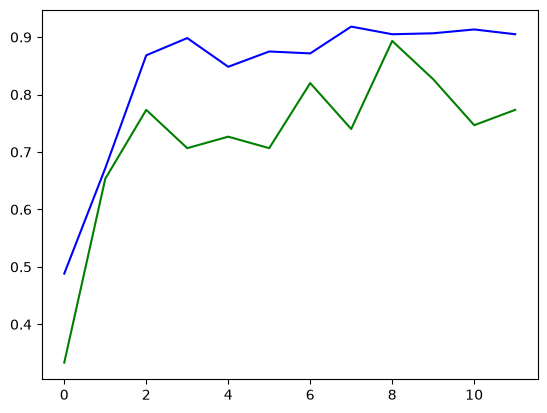

In [20]:
plt.plot(history.history['accuracy'], color='blue')
plt.plot(history.history['val_accuracy'], color='green')

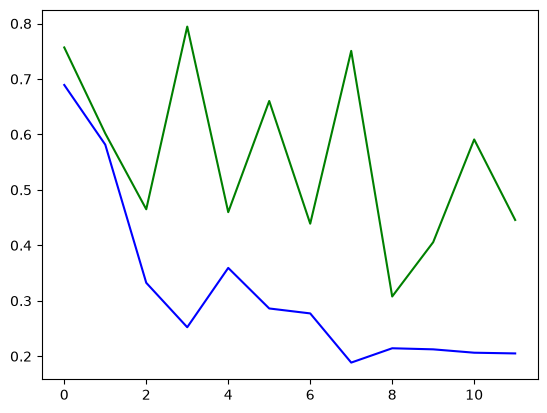

In [21]:
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='green')

Restart kernel

In [7]:
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

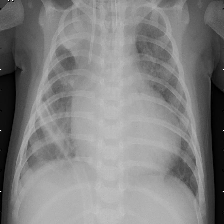

In [8]:
imgPath = os.path.join('datasets', 'XRay', 'img-opacity.jpeg')
img = load_img(imgPath, target_size=(224, 224), color_mode='grayscale')
img

In [9]:
img = img_to_array(img)/255

In [10]:
model = load_model('cnnxray.h5')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,253,091 (4.78 MB)

 Trainable params: 1,253,089 (4.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [11]:
import tensorflow as tf
model.predict(tf.expand_dims(img, axis=0))

I0000 00:00:1783590973.950267   46340 service.cc:153] XLA service 0x7e7b4002e6a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783590973.950287   46340 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783590973.965430   46340 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783590974.009971   46340 cuda_dnn.cc:461] Loaded cuDNN version 92400


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


I0000 00:00:1783590975.596286   46340 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


array([[0.98951155]], dtype=float32)